In [1]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
    make_animation,
    metrics_grid,
    plot_grid,
    plot_ball_behavior,
    plot_all_trajectories,
)
from sklearn.cluster import KMeans
from sklearn.svm import SVC
import plotly.express as px
from src.classify import classify_trajectories

In [3]:
model = "bruss"
ds_id = "param_sweep"
ds, output_dir = get_dataset(model, ds_id)
df = ds.df
df = expand_json_column(df, "original_point", "op", True)
df = expand_json_column(df, "initial_condition", "ic", True)
df = classify_trajectories(df)
df["ratio_b_a"] = df["B"] / df["A"]
df["ratio_d"] = df["Dv"] / df["Du"]

In [4]:
df_sub = df.sample(4)

In [5]:
for i, row in df_sub.iterrows():
    make_animation(ds.get_data(i), f"test_{i}", ".")

MovieWriter ffmpeg unavailable; using Pillow instead.
MovieWriter ffmpeg unavailable; using Pillow instead.
MovieWriter ffmpeg unavailable; using Pillow instead.
MovieWriter ffmpeg unavailable; using Pillow instead.


403


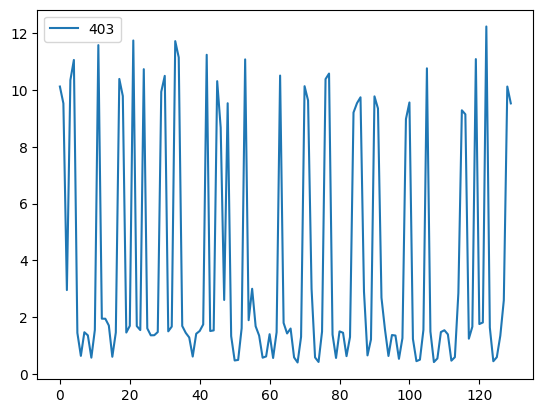

4867


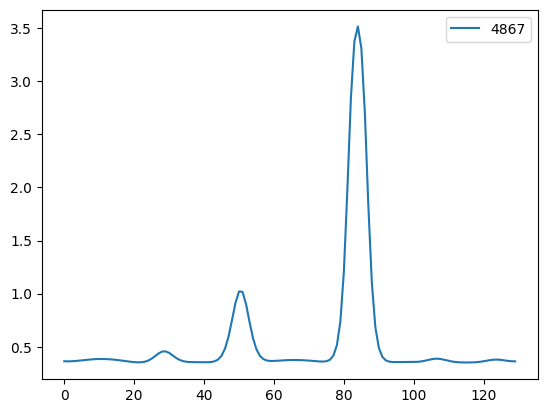

7132


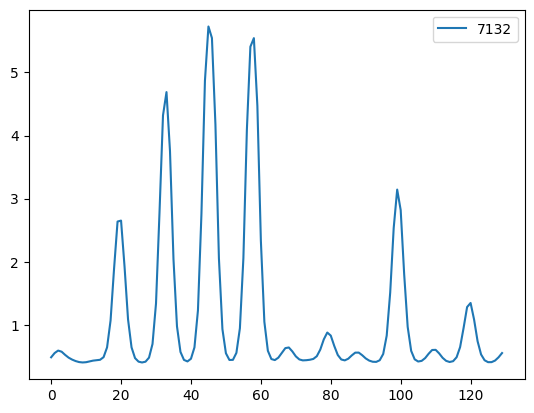

3317


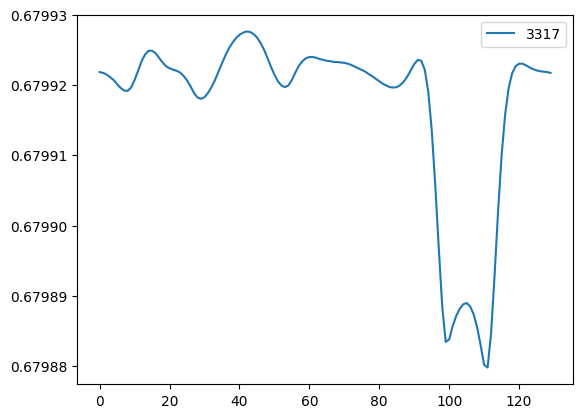

In [6]:
for i, row in df_sub.iterrows():
    print(i)
    d = ds.get_data(i)
    plt.plot(d[-1, 64, 0::2], label=i)
    plt.legend()
    plt.show()

In [9]:
df_sub["total_power"]

403     0.371648
4867    0.049726
7132    0.234243
3317    0.002241
Name: total_power, dtype: float64

In [20]:
df["q"] = np.log(df["mean_deviation"])

fig = px.scatter_3d(
    df,
    x="A",
    y="ratio_b_a",
    z="q", 
    color="category", 
    opacity=0.7,
)
fig.update_traces(marker_size=2)
fig.update_layout(
    scene=dict(
        xaxis_title="A",
        yaxis_title="B/A",
        zaxis_title="mean_dev"
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [22]:
lower = np.exp(-2)
higher = np.exp(2)

In [28]:
df["label"] = (df["mean_deviation"] < higher).astype(int)

In [29]:
model = SVC(kernel='rbf', probability=True)
model.fit(df[["A", "ratio_b_a"]], df["label"])

SVC(probability=True)

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but SVC was fitted with feature names



Text(0, 0.5, 'B/A')

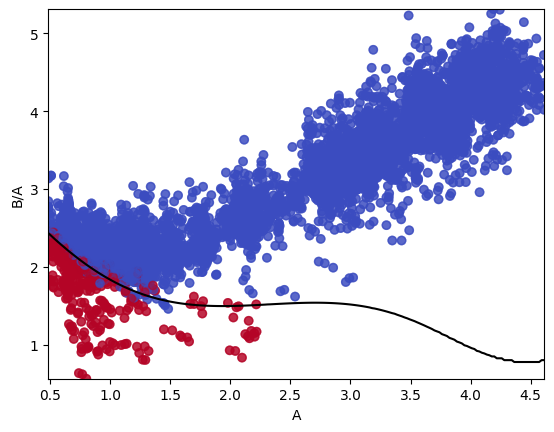

In [30]:
A_range = np.linspace(df["A"].min(), df["A"].max(), 200)
R_range = np.linspace(df["ratio_b_a"].min(), df["ratio_b_a"].max(), 200)
AA, RR = np.meshgrid(A_range, R_range)
XX = np.c_[AA.ravel(), RR.ravel()]
probs = model.predict_proba(XX)[:,1].reshape(AA.shape)

plt.contour(AA, RR, probs, levels=[0.5], colors='k')  # decision boundary
plt.scatter(df["A"], df["ratio_b_a"], c=df["label"], cmap="coolwarm", alpha=0.6)
plt.xlabel("A")
plt.ylabel("B/A")

<Axes: xlabel='ratio_b_a', ylabel='A'>

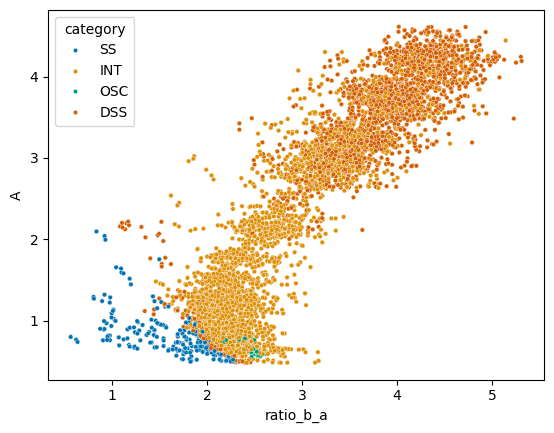

In [5]:
colorblind_palette = sns.color_palette("colorblind")

# Define a fixed hue mapping
categories = ["SS", "INT", "OSC", "DSS"]
hue_mapping = {cat: colorblind_palette[i] for i, cat in enumerate(categories)}

sns.scatterplot(df, x="ratio_b_a", y="A", hue="category", palette=hue_mapping, hue_order=categories, marker="o", s=10)


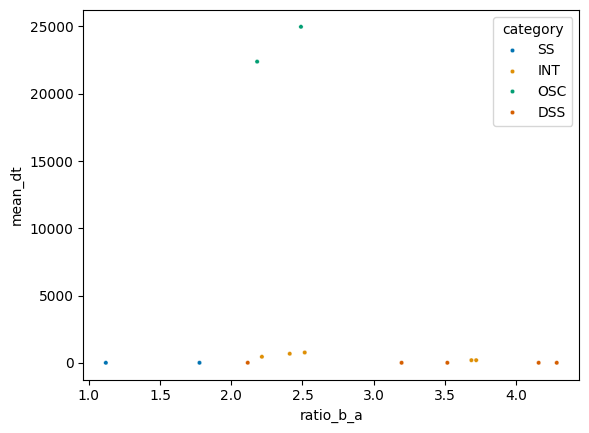

In [6]:
def sample_representative(df, proportions: dict, total_samples: int):
    features = ['A', 'B', 'Du', 'Dv']
    all_samples = []
    
    for category, prop in proportions.items():
        df_cat = df[df['category'] == category]
        k = min(int(total_samples * prop), len(df_cat))
        if k == 0:
            continue

        X = df_cat[features].to_numpy()
        km = KMeans(n_clusters=k, init='k-means++', n_init=5)
        km.fit(X)
        
        centers_df = df_cat.iloc[np.argmin(
            np.linalg.norm(X[:, None, :] - km.cluster_centers_[None, :, :], axis=2), axis=0
        )]
        all_samples.append(centers_df)

    return pd.concat(all_samples).reset_index(drop=True)

proportions = {"SS": 0.15, "OSC": 0.15, "INT": 0.35, "DSS": 0.35}
df_sampled = sample_representative(df, proportions, 15)
sns.scatterplot(df_sampled, x="ratio_b_a", y="mean_dt", hue="category", palette=hue_mapping, hue_order=categories, marker="o", s=10)
df_sampled.to_csv("../data/rep_samples.csv")